In [2]:
!pip install dagshub mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 7.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 47.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 13.3 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [3]:
import os
os.environ['MLFLOW_TRACKING_USERNAME'] = 'sophyrise'
os.environ['MLFLOW_TRACKING_PASSWORD'] = '95f86824d28eb66b760d891dfa5f39816ddea9c4'

import dagshub
dagshub.init(repo_owner='sophyrise', repo_name='house-prices-mlflow', mlflow=True)

import mlflow
mlflow.set_experiment("house-prices-experiment")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=24f582d2-0948-4686-a42c-4510b40c555d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=fcaaa24a07794a7abb4885870b0f10213009f9f401af3e36c037c38b7efe5ac3




Output()

Accessing as sophyrise

Initialized MLflow to track repo "sophyrise/house-prices-mlflow"

Repository sophyrise/house-prices-mlflow initialized!

MLflow tracking URI: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sopogurjishvili/house-prices-data/sample_submission.csv
/kaggle/input/datasets/sopogurjishvili/house-prices-data/train.csv
/kaggle/input/datasets/sopogurjishvili/house-prices-data/test.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/datasets/sopogurjishvili/house-prices-data/train.csv')
test = pd.read_csv('/kaggle/input/datasets/sopogurjishvili/house-prices-data/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# Cleaning

In [7]:
missing = train.isnull().sum() # each column, how much data is missing
missing_pct = (missing / len(train)) * 100 #each column it calculates what percentage is missing
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct}) # created new df
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending = False) # we need only problematic values so cnt>0. sort descend
print(missing_df)

              count        pct
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
GarageCond       81   5.547945
BsmtExposure     38   2.602740
BsmtFinType2     38   2.602740
BsmtQual         37   2.534247
BsmtCond         37   2.534247
BsmtFinType1     37   2.534247
MasVnrArea        8   0.547945
Electrical        1   0.068493


In [8]:
# drop columns if more than 80% is missing
cols_to_drop = missing_df[missing_df['pct'] > 80].index.tolist()
train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns:", cols_to_drop)

# drop outliers - models shouldn't learn that big house is cheap 
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 200000))].reset_index(drop=True)

# compress numbers so that model learns easily
train['SalePrice'] = np.log1p(train['SalePrice'])

all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0).reset_index(drop=True)
print("Combined shape:", all_data.shape)

Dropped columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
Combined shape: (2917, 76)


In [9]:
print(train.columns.tolist())
print(train.dtypes)

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSol

In [10]:
# Feature Engineering

In [11]:
none_cols = ['MasVnrType', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

mode_cols = ['MSZoning', 'Electrical', 'KitchenQual',
             'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']
for col in mode_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

print("Remaining NaNs:", all_data.isnull().sum().sum())

Remaining NaNs: 2


In [12]:
print(all_data.isnull().sum()[all_data.isnull().sum() > 0])

Utilities    2
dtype: int64


In [13]:
print(all_data['Utilities'].value_counts())


Utilities
AllPub    2914
NoSeWa       1
Name: count, dtype: int64


In [14]:
print(all_data.isnull().sum()[all_data.isnull().sum() > 0])
print("Total NaNs:", all_data.isnull().sum().sum())
print("Columns:", all_data.columns.tolist())

Utilities    2
dtype: int64
Total NaNs: 2
Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnP

In [15]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath'] = (all_data['FullBath'] +
                          0.5 * all_data['HalfBath'] +
                          all_data['BsmtFullBath'] +
                          0.5 * all_data['BsmtHalfBath'])
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodelAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['QualCond'] = all_data['OverallQual'] * all_data['OverallCond']

print("New shape:", all_data.shape)


New shape: (2917, 84)


In [16]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in qual_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(quality_map).fillna(0)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = all_data.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

for col in cat_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print("Shape:", all_data.shape)
print("Any remaining objects:", all_data.select_dtypes(include='object').shape[1])

Categorical columns to encode: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']
Shape: (2917, 84)
Any remaining objects: 0


In [17]:
from scipy.stats import skew

numeric_cols = all_data.select_dtypes(include=[np.number]).columns.tolist()
skewed = all_data[numeric_cols].apply(lambda x: skew(x.dropna()))
skewed = skewed[abs(skewed) > 0.75].index.tolist()

all_data[skewed] = np.log1p(all_data[skewed].clip(lower=0))

print(f"Log-transformed {len(skewed)} skewed features")
print("Shape:", all_data.shape)

Log-transformed 50 skewed features
Shape: (2917, 84)


In [18]:
n_train = len(train)
X = all_data[:n_train].copy()
X_test_final = all_data[n_train:].copy()
y = train['SalePrice'].values

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test_final:", X_test_final.shape)
print("y_train:", y_train.shape)

X_train: (1166, 84)
X_val: (292, 84)
X_test_final: (1459, 84)
y_train: (1166,)


In [19]:
## Feature Selection

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

In [21]:
corr = X.corrwith(pd.Series(y, index=X.index)).abs().sort_values(ascending=False)
print("Top 15 correlated features:")
print(corr.head(15))

Top 15 correlated features:
OverallQual    0.821405
TotalSF        0.817818
GrLivArea      0.737431
GarageCars     0.681033
ExterQual      0.680950
TotalBath      0.676678
KitchenQual    0.669990
GarageArea     0.656129
TotalBsmtSF    0.647563
1stFlrSF       0.615408
QualCond       0.607983
FullBath       0.595899
HouseAge       0.587767
YearBuilt      0.587043
RemodelAge     0.568529
dtype: float64


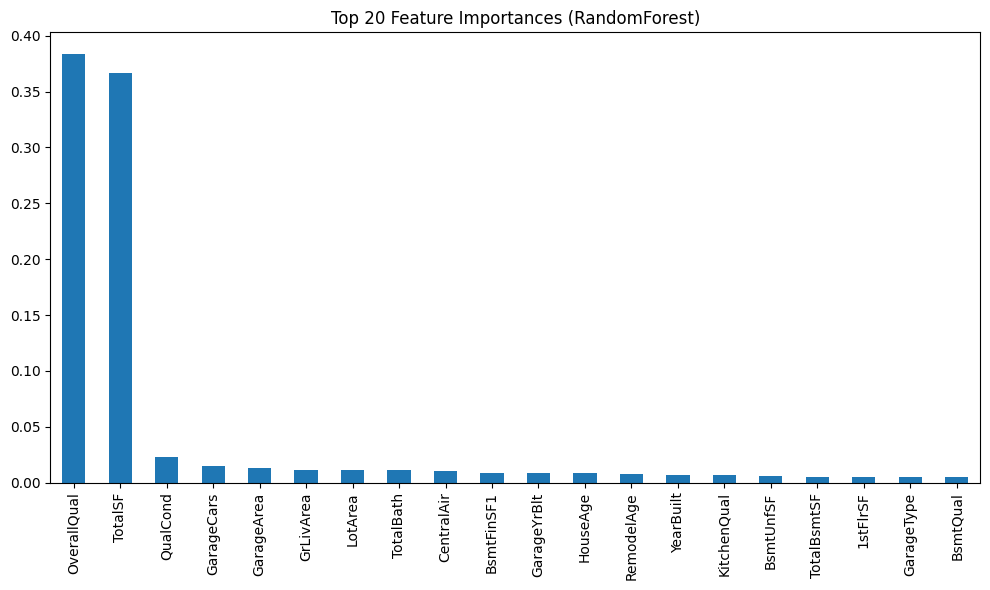


RF selected 19 features
['OverallQual', 'TotalSF', 'QualCond', 'GarageCars', 'GarageArea', 'GrLivArea', 'LotArea', 'TotalBath', 'CentralAir', 'BsmtFinSF1', 'GarageYrBlt', 'HouseAge', 'RemodelAge', 'YearBuilt', 'KitchenQual', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', 'GarageType']


In [22]:
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances[:20].plot(kind='bar')
plt.title('Top 20 Feature Importances (RandomForest)')
plt.tight_layout()
plt.show()

top_rf_features = importances[importances > 0.005].index.tolist()
print(f"\nRF selected {len(top_rf_features)} features")
print(top_rf_features)

In [23]:
selector = SelectKBest(f_regression, k=50)
selector.fit(X_train, y_train)
kbest_features = X_train.columns[selector.get_support()].tolist()
print(f"KBest selected {len(kbest_features)} features:")
print(kbest_features)

KBest selected 50 features:
['LotFrontage', 'LotArea', 'LotShape', 'Neighborhood', 'HouseStyle', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'MasVnrArea', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'SaleCondition', 'TotalSF', 'TotalBath', 'HouseAge', 'RemodelAge', 'HasGarage', 'HasBsmt', 'QualCond']


In [24]:
# Training

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [26]:
with mlflow.start_run(run_name="underfitted_linear_regression"):
    model = LinearRegression()
    features = ['OverallQual', 'GrLivArea']
    model.fit(X_train[features], y_train)
    
    train_rmse = rmse(y_train, model.predict(X_train[features]))
    val_rmse = rmse(y_val, model.predict(X_val[features]))
    
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("n_features", 2)
    mlflow.log_param("note", "intentionally_underfitted")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("overfit_gap", val_rmse - train_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print(f"[UNDERFITTED] Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
    print("Both errors high = model too simple = UNDERFITTING")

2026/04/10 18:23:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:23:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[UNDERFITTED] Train RMSE: 0.1953 | Val RMSE: 0.1892
Both errors high = model too simple = UNDERFITTING
🏃 View run underfitted_linear_regression at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/35f0a07001404802846dccc8dd2d1389
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


In [27]:
with mlflow.start_run(run_name="overfitted_random_forest"):
    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,      
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    train_rmse = rmse(y_train, model.predict(X_train))
    val_rmse = rmse(y_val, model.predict(X_val))
    
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("note", "intentionally_overfitted")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("overfit_gap", val_rmse - train_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print(f"[OVERFITTED] Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
    print("Train error very low, val error high = OVERFITTING")

2026/04/10 18:23:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:24:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[OVERFITTED] Train RMSE: 0.0487 | Val RMSE: 0.1410
Train error very low, val error high = OVERFITTING
🏃 View run overfitted_random_forest at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/34151c7b13b947d59854fded0a148ee1
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


In [28]:
for alpha in [0.1, 1.0, 10.0, 100.0]:
    with mlflow.start_run(run_name=f"ridge_alpha_{alpha}"):
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        
        train_rmse = rmse(y_train, model.predict(X_train))
        val_rmse = rmse(y_val, model.predict(X_val))
        
        mlflow.log_param("model", "Ridge")
        mlflow.log_param("alpha", alpha)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("overfit_gap", val_rmse - train_rmse)
        mlflow.sklearn.log_model(model, "model")
        
        print(f"Ridge alpha={alpha}: Train={train_rmse:.4f} Val={val_rmse:.4f}")

2026/04/10 18:24:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:24:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge alpha=0.1: Train=0.1101 Val=0.1213
🏃 View run ridge_alpha_0.1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/56b3611727f74db4aa43ddc374120643
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:24:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:24:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge alpha=1.0: Train=0.1109 Val=0.1201
🏃 View run ridge_alpha_1.0 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/c758cb97307e46f0b98451745ab68a71
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:25:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:25:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge alpha=10.0: Train=0.1136 Val=0.1216
🏃 View run ridge_alpha_10.0 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/412c1bb55dfe407685545a69e081708f
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:25:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:25:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge alpha=100.0: Train=0.1198 Val=0.1306
🏃 View run ridge_alpha_100.0 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/deed4e24d050409d8e545d3bba39affe
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


In [29]:
from sklearn.linear_model import Lasso
for alpha in [0.0001, 0.001, 0.01, 0.1]:
    with mlflow.start_run(run_name=f"lasso_alpha_{alpha}"):
        model = Lasso(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        
        train_rmse = rmse(y_train, model.predict(X_train))
        val_rmse = rmse(y_val, model.predict(X_val))
        
        mlflow.log_param("model", "Lasso")
        mlflow.log_param("alpha", alpha)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("overfit_gap", val_rmse - train_rmse)
        mlflow.sklearn.log_model(model, "model")
        
        print(f"Lasso alpha={alpha}: Train={train_rmse:.4f} Val={val_rmse:.4f}")

2026/04/10 18:25:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:25:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=0.0001: Train=0.1105 Val=0.1196
🏃 View run lasso_alpha_0.0001 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/6ba98d1037674c44bd347e4016c84966
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:26:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:26:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=0.001: Train=0.1157 Val=0.1223
🏃 View run lasso_alpha_0.001 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/3cd10046f38f454894b4e8ad8b54274a
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:26:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:26:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=0.01: Train=0.1332 Val=0.1422
🏃 View run lasso_alpha_0.01 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/5ed916dc756e43bfb6996a2c1d52e82b
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:26:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:27:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso alpha=0.1: Train=0.1679 Val=0.1803
🏃 View run lasso_alpha_0.1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/7102643edb824de1b7c1b3f1ee9ba061
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


In [30]:
gb_params = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.01},
]

for params in gb_params:
    run_name = f"gbm_n{params['n_estimators']}_d{params['max_depth']}_lr{params['learning_rate']}"
    with mlflow.start_run(run_name=run_name):
        model = GradientBoostingRegressor(**params, random_state=42)
        model.fit(X_train, y_train)
        
        train_rmse = rmse(y_train, model.predict(X_train))
        val_rmse = rmse(y_val, model.predict(X_val))
        
        mlflow.log_params(params)
        mlflow.log_param("model", "GradientBoosting")
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("overfit_gap", val_rmse - train_rmse)
        mlflow.sklearn.log_model(model, "model")
        
        print(f"GBM {params}: Train={train_rmse:.4f} Val={val_rmse:.4f}")

2026/04/10 18:27:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:27:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GBM {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}: Train=0.0742 Val=0.1187
🏃 View run gbm_n100_d3_lr0.1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/a37a9957b5d1491bb36c5afe9da681e3
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:27:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:27:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GBM {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}: Train=0.0536 Val=0.1254
🏃 View run gbm_n200_d4_lr0.05 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/846ca7ba76f247b2a23da9725d1c3fca
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:28:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 18:28:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GBM {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01}: Train=0.0507 Val=0.1333
🏃 View run gbm_n500_d5_lr0.01 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/8ab6a12a4781465a8f099bf1210ded11
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


In [31]:
xgb_params = [
    {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 1000, "max_depth": 4, "learning_rate": 0.01, "subsample": 0.7},
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.9},
]

for params in xgb_params:
    run_name = f"xgb_n{params['n_estimators']}_d{params['max_depth']}_lr{params['learning_rate']}"
    with mlflow.start_run(run_name=run_name):
        model = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
        
        train_rmse = rmse(y_train, model.predict(X_train))
        val_rmse = rmse(y_val, model.predict(X_val))
        
        mlflow.log_params(params)
        mlflow.log_param("model", "XGBoost")
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("overfit_gap", val_rmse - train_rmse)
        mlflow.xgboost.log_model(model, "model")
        
        print(f"XGB {params}: Train={train_rmse:.4f} Val={val_rmse:.4f}")

2026/04/10 18:28:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGB {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}: Train=0.0523 Val=0.1197
🏃 View run xgb_n500_d3_lr0.05 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/39774d73db8d495cad547c9b749ebb6b
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:28:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGB {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.7}: Train=0.0564 Val=0.1186
🏃 View run xgb_n1000_d4_lr0.01 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/acbf9cc4700548a6b1c2767db6547c76
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


2026/04/10 18:29:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGB {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9}: Train=0.0052 Val=0.1353
🏃 View run xgb_n500_d6_lr0.05 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/e25c38f9254a433db9a28b214c81bdf9
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1


In [32]:
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("house-prices-experiment")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.val_rmse ASC"]
)

best_run = runs[0]
print(f"Best run: {best_run.info.run_id}")
print(f"Best val_rmse: {best_run.data.metrics['val_rmse']:.4f}")
print(f"Best model: {best_run.data.params.get('model')}")

# Register it
model_uri = f"runs:/{best_run.info.run_id}/model"
registered = mlflow.register_model(model_uri, "HousePricesBestModel")
print("Registered model version:", registered.version)

Best run: acbf9cc4700548a6b1c2767db6547c76
Best val_rmse: 0.1186
Best model: XGBoost


Successfully registered model 'HousePricesBestModel'.


MlflowException: Unable to find a logged_model with artifact_path model under run acbf9cc4700548a6b1c2767db6547c76

In [33]:
client = mlflow.tracking.MlflowClient()
versions = client.search_model_versions("name='HousePricesBestModel'")
for v in versions:
    print(f"Version: {v.version}")
    print(f"Run ID: {v.run_id}")
    print(f"Status: {v.status")
    print(f"Source: {v.source}")

SyntaxError: f-string: expecting '}' (3189332144.py, line 6)

In [37]:
client = mlflow.tracking.MlflowClient()
versions = client.search_model_versions("name='HousePricesBestModel'")
for v in versions:
    print(f"Version: {v.version}")
    print(f"Run ID: {v.run_id}")
    print(f"Status: {v.status}")
    print(f"Source: {v.source}")

In [38]:
best_run_id = "acbf9cc4700548a6b1c2767db6547c76"
model_uri = f"runs:/{best_run_id}/model"
print("Trying to register:", model_uri)

registered = mlflow.register_model(model_uri, "HousePricesBestModel")
print("Registered model version:", registered.version)

Trying to register: runs:/acbf9cc4700548a6b1c2767db6547c76/model


Registered model 'HousePricesBestModel' already exists. Creating a new version of this model...


MlflowException: Unable to find a logged_model with artifact_path model under run acbf9cc4700548a6b1c2767db6547c76

In [39]:
with mlflow.start_run(run_name="best_xgboost_final"):
    best_model = XGBRegressor(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.01,
        subsample=0.7,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    best_model.fit(X_train, y_train)
    train_rmse = rmse(y_train, best_model.predict(X_train))
    val_rmse = rmse(y_val, best_model.predict(X_val))
    
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.01)
    mlflow.log_param("subsample", 0.7)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    
    mlflow.xgboost.log_model(
        best_model,
        "model",
        registered_model_name="HousePricesBestModel"
    )
    
    print(f"Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
    print("Model registered!")

2026/04/10 18:32:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'HousePricesBestModel' already exists. Creating a new version of this model...
2026/04/10 18:33:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePricesBestModel, version 1
Created version '1' of model 'HousePricesBestModel'.


Train RMSE: 0.0564 | Val RMSE: 0.1186
Model registered!
🏃 View run best_xgboost_final at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1/runs/cffe7dcccb3446f4ba91ad3b3bcbf03e
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/1
